In [1]:
#!/usr/bin/env python3
import pandas as pd
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.kernel_ridge import KernelRidge
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Charger le dataset
Dataset = pd.read_csv("vinted_data.csv", sep=',', decimal=',')

Dataset.head()
Dataset.info()
Dataset.isna().sum()


<class 'pandas.DataFrame'>
RangeIndex: 384 entries, 0 to 383
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   url         384 non-null    str    
 1   etat        384 non-null    str    
 2   matiere     33 non-null     str    
 3   couleur     384 non-null    str    
 4   date        384 non-null    str    
 5   categorie   384 non-null    str    
 6   pays        262 non-null    str    
 7   likes       378 non-null    float64
 8   prix        384 non-null    str    
 9   prix_total  384 non-null    str    
 10  collection  384 non-null    str    
dtypes: float64(1), str(10)
memory usage: 33.1 KB


url             0
etat            0
matiere       351
couleur         0
date            0
categorie       0
pays          122
likes           6
prix            0
prix_total      0
collection      0
dtype: int64

In [3]:
print(Dataset.shape)

(384, 11)


In [4]:
Dataset.duplicated().sum()

np.int64(0)

In [5]:
# Remplacer les valeurs manquantes de la colonne "matiere" par "Non précisée"
Dataset["matiere"] = Dataset["matiere"].fillna("Non précisée")

In [6]:
# Remplacer les valeurs manquantes de la colonne "pays" par "Inconnu"
Dataset["pays"] = Dataset["pays"].fillna("Inconnu")

In [7]:
# Remplacer les valeurs manquantes de la colonne "likes" par 0
Dataset["likes"] = Dataset["likes"].fillna(0)


In [8]:
# Supprimer les lignes où la conversion a échoué (valeurs NaN)
Dataset.drop(columns=["url"], inplace=True)

In [9]:
Dataset.drop(columns=["pays"], inplace=True)

In [10]:
print(Dataset.isnull().sum())

etat          0
matiere       0
couleur       0
date          0
categorie     0
likes         0
prix          0
prix_total    0
collection    0
dtype: int64


In [11]:
# Convertir les colonnes "likes", "prix" et "prix_total" en numérique, en remplaçant les valeurs non convertibles par NaN
Dataset["prix"] = (
    Dataset["prix"]
    .astype(str)
    .str.replace("\u202f", "", regex=False)
    .str.replace("\xa0", "", regex=False)
    .str.replace("€", "", regex=False)
    .str.replace(",", ".", regex=False)
    .str.strip()
)

Dataset["prix"] = pd.to_numeric(Dataset["prix"], errors="coerce")
Dataset["prix_total"] = (
    Dataset["prix_total"]
    .astype(str)
    .str.replace("\u202f", "", regex=False)
    .str.replace("\xa0", "", regex=False)
    .str.replace("€", "", regex=False)
    .str.replace(",", ".", regex=False)
    .str.strip()
)

Dataset["prix_total"] = pd.to_numeric(Dataset["prix_total"], errors="coerce")

In [12]:
#date de publication

def convertir_date_en_jours(texte):
    '''
    Convertit une date en jours.
    '''
    texte = texte.lower()
    
    # heures -> 0 jour
    if "heure" in texte:
        return 0
    
    # jours
    elif "jour" in texte:
        nombre = re.search(r"\d+", texte)
        
        if nombre:
            return int(nombre.group())
        
        # cas "un jour"
        elif "un" in texte:
            return 1
    
    # mois
    elif "mois" in texte:
        nombre = re.search(r"\d+", texte)
        
        if nombre:
            return int(nombre.group()) * 30
        
        elif "un" in texte:
            return 30
    

    return None

In [13]:
# Appliquer la fonction de conversion à la colonne "date"
Dataset['date']=Dataset['date'].apply(convertir_date_en_jours)

In [14]:
# Supprimer les lignes où la conversion a échoué (valeurs NaN)
Dataset = Dataset.dropna(subset=["date"])

In [15]:
Dataset.head()

,etat,matiere,couleur,date,categorie,likes,prix,prix_total,collection
0,Neuf sans étiquette,Non précisée,"Crème, Noir",0.0,Sweats et sweats à capuche,21.0,7.0,7.70,femme
1,Très bon état,Coton,Blanc,0.0,Robes,58.0,22.0,23.80,femme
2,Très bon état,Non précisée,Bleu,1.0,Jeans,24.0,15.0,16.40,femme
3,Neuf sans étiquette,"Coton, Lin",Beige,0.0,Blazers et tailleurs,62.0,35.0,37.45,femme
4,Très bon état,Non précisée,Gris,0.0,Robes,38.0,22.0,23.97,femme


In [16]:
Dataset.to_csv("vinted_data_clean.csv", index=False)
dataset_clean = pd.read_csv("vinted_data_clean.csv", sep=',')

In [17]:
# Afficher les statistiques descriptives, la forme du dataset et le nombre de valeurs manquantes
print(dataset_clean.shape)
print(dataset_clean.isnull().sum())

(381, 9)
etat          0
matiere       0
couleur       0
date          0
categorie     0
likes         0
prix          0
prix_total    0
collection    0
dtype: int64


In [18]:
dataset_clean.describe()

,date,likes,prix,prix_total
count,381.000000,381.000000,381.000000,381.000000
mean,1.320210,36.068241,10.329344,11.472047
std,23.051369,30.779360,7.595969,8.064009
min,0.000000,0.000000,1.000000,1.750000
25%,0.000000,18.000000,5.000000,5.950000
50%,0.000000,28.000000,8.000000,9.100000
75%,0.000000,44.000000,15.000000,16.380000
max,450.000000,217.000000,55.000000,59.200000


In [19]:
dataset_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 381 entries, 0 to 380
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   etat        381 non-null    str    
 1   matiere     381 non-null    str    
 2   couleur     381 non-null    str    
 3   date        381 non-null    float64
 4   categorie   381 non-null    str    
 5   likes       381 non-null    float64
 6   prix        381 non-null    float64
 7   prix_total  381 non-null    float64
 8   collection  381 non-null    str    
dtypes: float64(4), str(5)
memory usage: 26.9 KB


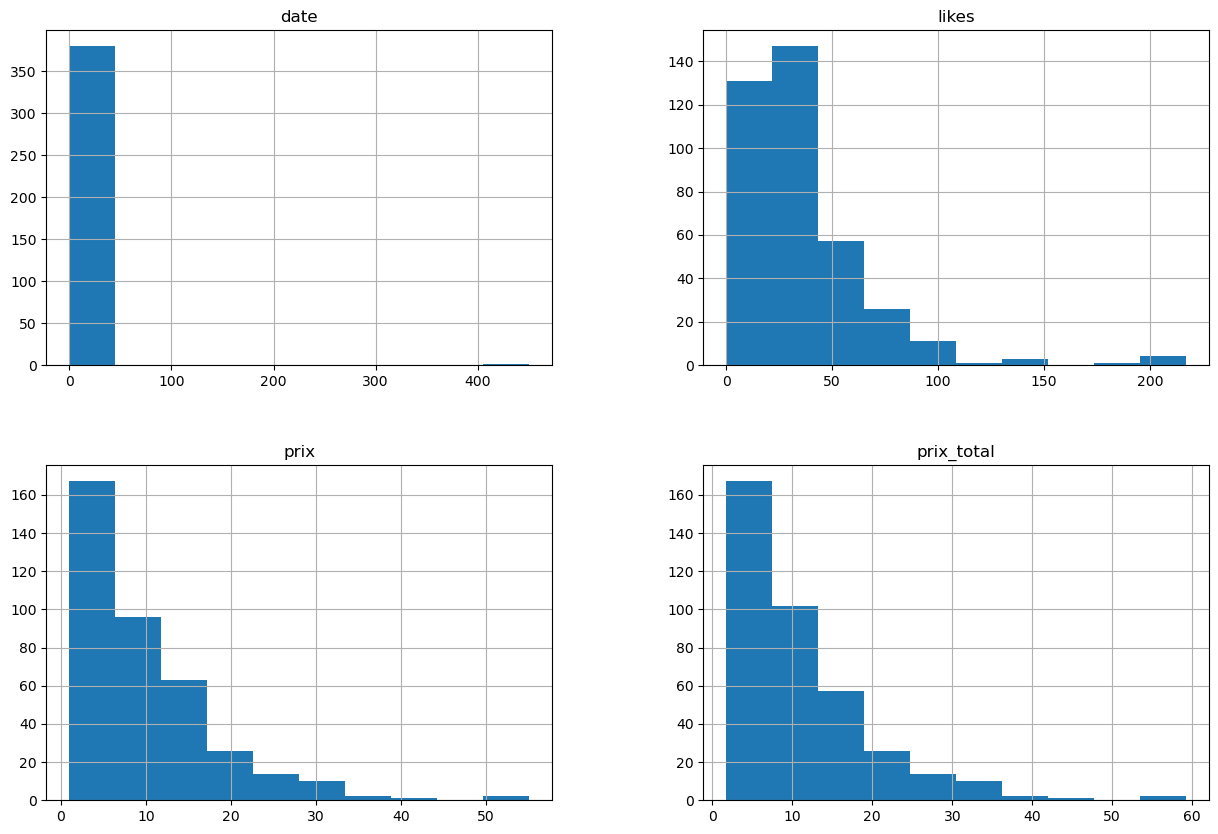

In [20]:
dataset_clean.hist(figsize=(15,10))
plt.show()

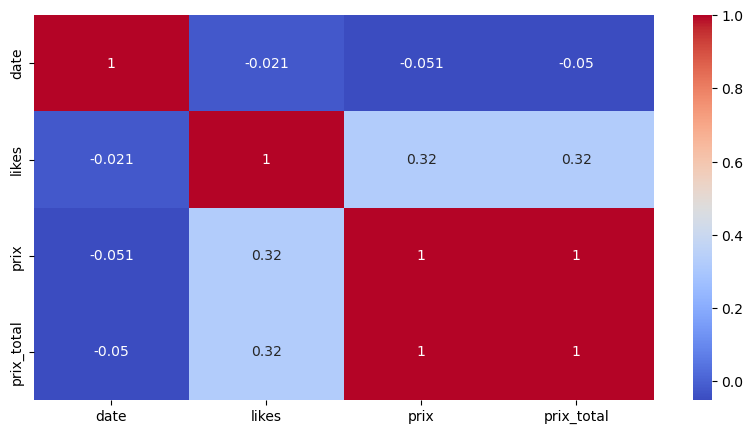

In [21]:
Dataset_numeric = dataset_clean.select_dtypes(include=[np.number])

plt.figure(figsize=(10,5))
sns.heatmap(Dataset_numeric.corr(), annot=True, cmap='coolwarm')
plt.show()

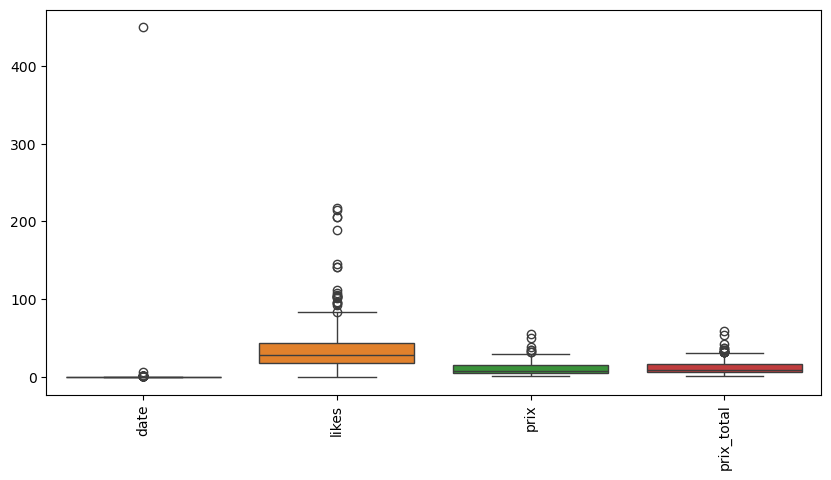

In [22]:
plt.figure(figsize=(10,5))
sns.boxplot(data=dataset_clean.select_dtypes(include=[np.number]))
plt.xticks(rotation=90)
plt.show()